# Phase 2 — Preprocessing + Modele Baseline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import random
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print('libs OK | seed fixe a', SEED)

libs OK | seed fixe a 42


## 1. Chargement des donnees

In [2]:
train_df = pd.read_csv('../data/UNSW_NB15_training-set.csv')
test_df  = pd.read_csv('../data/UNSW_NB15_testing-set.csv')
print('Train:', train_df.shape, '| Test:', test_df.shape)

Train: (82332, 45) | Test: (175341, 45)


## 2. Preprocessing

In [3]:
def preprocess(train_df, test_df):
    drop_cols = ['id', 'attack_cat']
    train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
    test_df  = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

    for df in [train_df, test_df]:
        df.replace([np.inf, -np.inf], np.nan, inplace=True)
    median_vals = train_df.median(numeric_only=True)
    train_df.fillna(median_vals, inplace=True)
    test_df.fillna(median_vals, inplace=True)

    cat_cols = train_df.select_dtypes(include=['object','str']).columns.tolist()
    cat_cols = [c for c in cat_cols if c != 'label']
    le = LabelEncoder()
    for col in cat_cols:
        train_df[col] = le.fit_transform(train_df[col].astype(str))
        known = set(le.classes_)
        test_df[col] = test_df[col].astype(str).apply(lambda x: x if x in known else le.classes_[0])
        test_df[col] = le.transform(test_df[col])

    X_train = train_df.drop('label', axis=1).values.astype(np.float32)
    y_train = train_df['label'].values.astype(np.float32)
    X_test  = test_df.drop('label', axis=1).values.astype(np.float32)
    y_test  = test_df['label'].values.astype(np.float32)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    return X_train, y_train, X_test, y_test, scaler

X_train, y_train, X_test, y_test, scaler = preprocess(train_df.copy(), test_df.copy())
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print(f"Taux attaque train : {y_train.mean()*100:.1f}%")

X_train: (82332, 42)
X_test : (175341, 42)
Taux attaque train : 55.1%


## 3. Architecture MLP

In [4]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=X_train.shape[1])
print(model)
print(f'Parametres : {sum(p.numel() for p in model.parameters()):,}')

MLP(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)
Parametres : 15,873


## 4. Entrainement

Epoch 05/30 | Loss: 0.1387
Epoch 10/30 | Loss: 0.1169
Epoch 15/30 | Loss: 0.1077
Epoch 20/30 | Loss: 0.1033
Epoch 25/30 | Loss: 0.1007
Epoch 30/30 | Loss: 0.0977


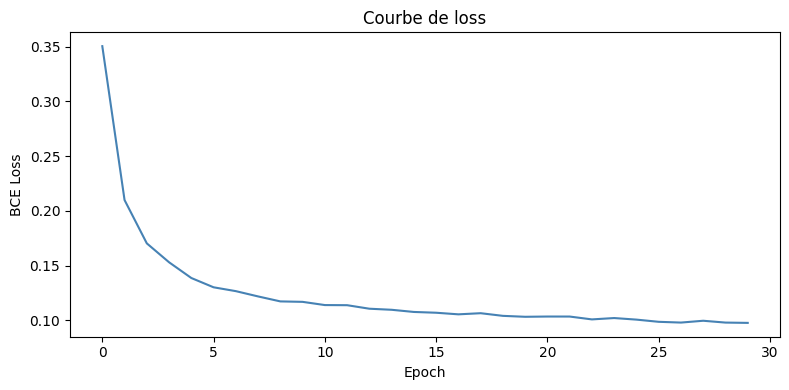

In [5]:
X_train_t = torch.FloatTensor(X_train)
y_train_t  = torch.FloatTensor(y_train)
X_test_t   = torch.FloatTensor(X_test)

optimizer    = torch.optim.Adam(model.parameters(), lr=0.001)
criterion    = nn.BCELoss()
EPOCHS, BATCH = 30, 512
n            = len(X_train_t)
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    idx = torch.randperm(n)
    for start in range(0, n, BATCH):
        xb = X_train_t[idx[start:start+BATCH]]
        yb = y_train_t[idx[start:start+BATCH]]
        optimizer.zero_grad()
        loss = criterion(model(xb).squeeze(), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / max(1, n // BATCH)
    train_losses.append(avg)
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1:02d}/{EPOCHS} | Loss: {avg:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue')
plt.title('Courbe de loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.tight_layout()
plt.savefig('../results/training_loss.png', dpi=150)
plt.show()

## 5. Evaluation du baseline

=== RESULTATS BASELINE ===
F1-score  : 0.9110
Precision : 0.9879
Recall    : 0.8452
PR-AUC    : 0.9881


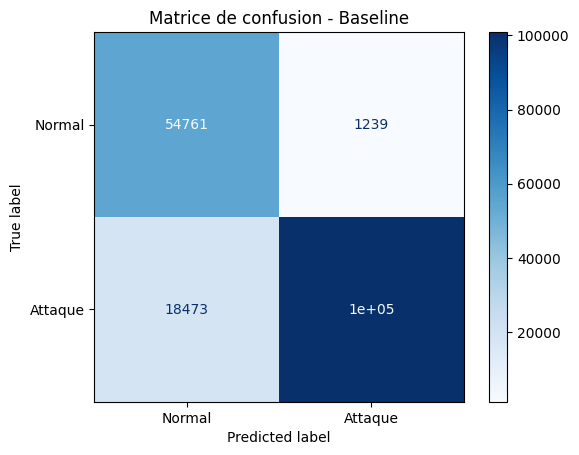

In [6]:
model.eval()
with torch.no_grad():
    y_prob = model(X_test_t).squeeze().numpy()
    y_pred = (y_prob >= 0.5).astype(int)

print('=== RESULTATS BASELINE ===')
print(f'F1-score  : {f1_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'PR-AUC    : {average_precision_score(y_test, y_prob):.4f}')

disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Normal', 'Attaque'])
disp.plot(cmap='Blues')
plt.title('Matrice de confusion - Baseline')
plt.savefig('../results/confusion_baseline.png', dpi=150)
plt.show()

## 6. Sauvegarder le modele

In [7]:
torch.save(model.state_dict(), '../results/baseline_model.pth')
print('Modele sauvegarde => Phase 3 : attaques adversariales')

Modele sauvegarde => Phase 3 : attaques adversariales
